In [ ]:
!pip install seaborn matplotlib

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [15]:
clean_data.shape

(3618604, 22)

In [16]:
df = clean_data.copy()

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3618604 entries, 0 to 3618603
Data columns (total 22 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               float64        
 4   trip_distance                 float64        
 5   fare_type_id                  float64        
 6   store_and_fwd_flag            str            
 7   pickup_location_id            int32          
 8   dropoff_location_id           int32          
 9   payment_type                  int64          
 10  fare_amount                   float64        
 11  extra_amount                  float64        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amou

In [18]:
df['passenger_count'].isna().sum() / df.shape[0]

np.float64(0.2991648160450826)

In [19]:
df['passenger_count'].describe()

count    2.536045e+06
mean     1.254294e+00
std      6.672072e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64

# check the distribution

In [ ]:
df['passenger_count'].value_counts(dropna=False)

passenger_count
1.0    2071006
2.0     321339
3.0      69851
4.0      45924
0.0      14086
5.0       9025
6.0       4811
8.0          2
7.0          1
Name: count, dtype: int64

<Axes: xlabel='passenger_count'>

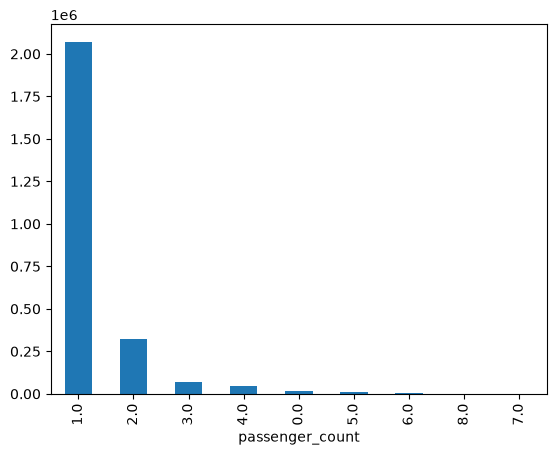

In [21]:
df['passenger_count'].value_counts().plot(kind='bar')

# check passenger null values

In [23]:
tempdf = df[df['passenger_count'].isna()].copy()

In [42]:
cols = [
    "passenger_count",
    "fare_type_id",
    "store_and_fwd_flag",
    "congestion_surcharge_amount",
    "airport_fee_amount"
]

tempdf[cols].isna().sum()


passenger_count                1082559
fare_type_id                   1082559
store_and_fwd_flag             1082559
congestion_surcharge_amount    1082559
airport_fee_amount             1082559
dtype: int64

In [43]:
df.dropna(subset=['passenger_count'], inplace=True)

In [44]:
df.shape

(2536045, 22)

In [25]:
tempdf = pd.read_parquet("../raw_data/yellow_tripdata_2026-01.parquet")

In [27]:
tempdf = tempdf[tempdf['passenger_count'].isna()]

<Axes: xlabel='tpep_pickup_datetime'>

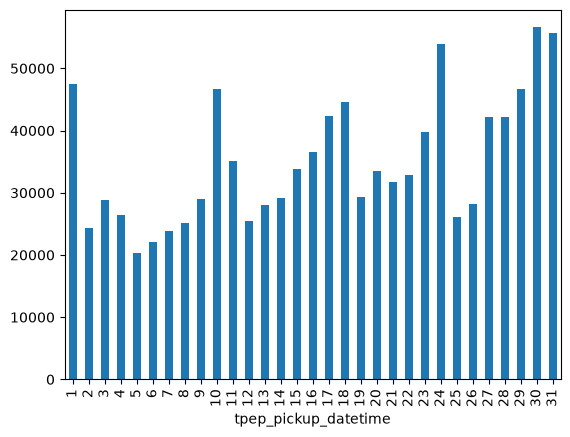

In [28]:
tempdf['tpep_pickup_datetime'].dt.day.value_counts(dropna=False).sort_index().plot(kind="bar")

<Axes: xlabel='tpep_pickup_datetime'>

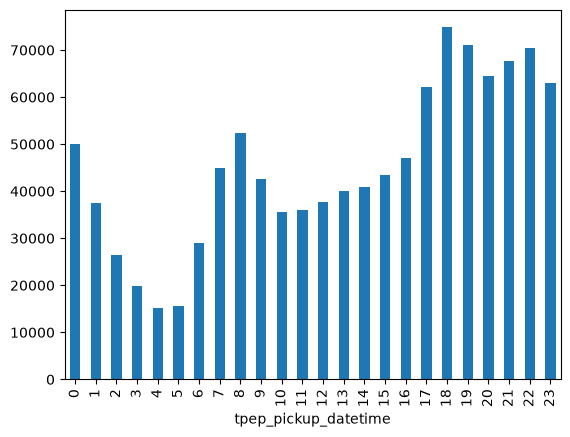

In [29]:
tempdf['tpep_pickup_datetime'].dt.hour.value_counts(dropna=False).sort_index().plot(kind='bar')

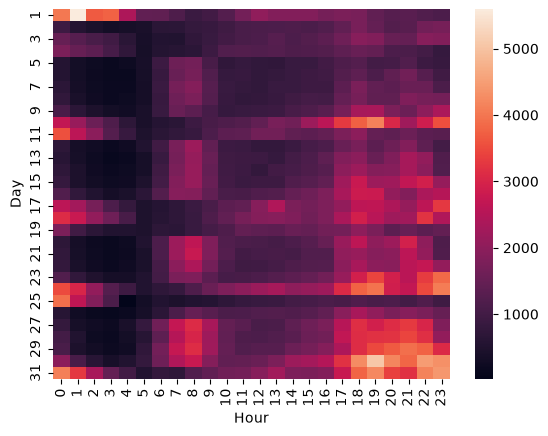

In [30]:
sns.heatmap(pd.crosstab(
    tempdf['tpep_pickup_datetime'].dt.day,
    tempdf['tpep_pickup_datetime'].dt.hour,
))

plt.xlabel('Hour')
plt.ylabel('Day')
plt.show()

# check trips of passenger count > 6

In [45]:
df = df[df['passenger_count'] <= 6]

In [46]:
df.shape

(2536042, 22)

# check for 0 passengers 

In [48]:
df[df['passenger_count'] == 0].sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,mta_tax_amount,tip_amount,tolls_amount,improvement_surcharge_amount,total_amount,congestion_surcharge_amount,airport_fee_amount,cbd_congestion_fee_amount,vendor_name,trip_duration
1006333,1,2026-01-13 15:31:16,2026-01-13 15:46:07,0.0,1.6,1.0,N,237,142,1,...,0.5,4.1,0.0,1.0,24.8,2.5,0.0,0.0,"Creative Mobile Technologies, LLC",0 days 00:14:51


In [49]:
(df['passenger_count'].value_counts()[0] / df.shape[0]) * 100

np.float64(0.555432441576283)

In [50]:
df = df[df['passenger_count'] > 0]

In [51]:
df['passenger_count'].value_counts()

passenger_count
1.0    2071006
2.0     321339
3.0      69851
4.0      45924
5.0       9025
6.0       4811
Name: count, dtype: int64

# change data type

In [52]:
df['passenger_count'] = df['passenger_count'].astype('int8')

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 2521956 entries, 0 to 2536044
Data columns (total 22 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float64        
 5   fare_type_id                  float64        
 6   store_and_fwd_flag            str            
 7   pickup_location_id            int32          
 8   dropoff_location_id           int32          
 9   payment_type                  int64          
 10  fare_amount                   float64        
 11  extra_amount                  float64        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amount  f

In [54]:
df.shape

(2521956, 22)

# vendor 6 only has dirty data for passenger count

In [55]:
df['vendor_id'].value_counts()

vendor_id
2    1974206
1     547750
Name: count, dtype: int64

# save to clean data

In [56]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

# function to clean passenger count

In [57]:
def clean_passenger_count(df):
    df.dropna(subset=['passenger_count'], inplace=True)
    df = df[df['passenger_count'] <= 6]
    df = df[df['passenger_count'] > 0]
    df['passenger_count'] = df['passenger_count'].astype('int8')